In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

final_model = joblib.load('../models/lgbm_tuned_clean.pkl')

with open('../models/lgbm_tuned_clean_threshold.json') as f:
    final_threshold = json.load(f)['threshold']

print(f'X_test shape: {X_test.shape}')
print(f'y_test death rate: {y_test.mean():.3f}')
print(f'Final threshold: {final_threshold}')

X_test shape: (18343, 263)
y_test death rate: 0.086
Final threshold: 0.5


In [2]:
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= final_threshold).astype(int)

print(f'Predicted death rate: {y_pred.mean():.3f}')
print(f'Mean predicted probability: {y_proba.mean():.3f}')
print(f'Min probability: {y_proba.min():.3f}')
print(f'Max probability: {y_proba.max():.3f}')

Predicted death rate: 0.121
Mean predicted probability: 0.171
Min probability: 0.000
Max probability: 1.000


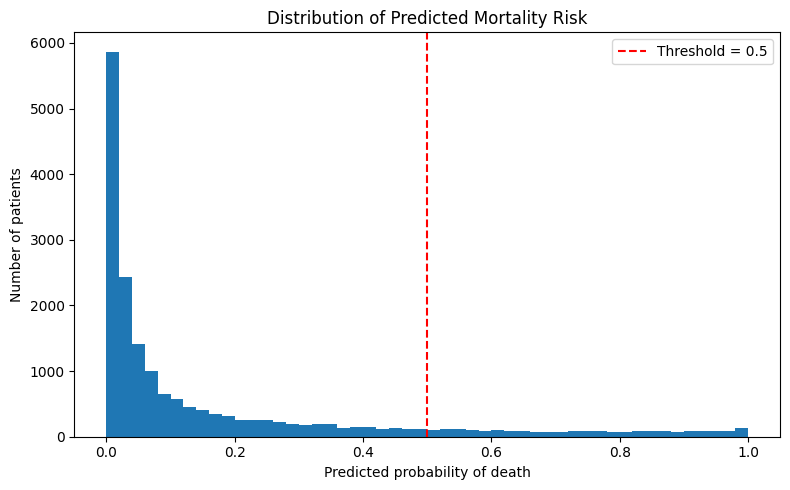

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_proba, bins=50)
plt.axvline(final_threshold, color='red', linestyle='--', label=f'Threshold = {final_threshold}')
plt.xlabel('Predicted probability of death')
plt.ylabel('Number of patients')
plt.title('Distribution of Predicted Mortality Risk')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
X_shap = X_test.copy()

print(f'X_shap shape: {X_shap.shape}')

X_shap shape: (18343, 263)


In [5]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

print('SHAP values calculated.')

SHAP values calculated.


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
type(shap_values)

numpy.ndarray

In [7]:
shap_values.shape

(18343, 263)

In [8]:
shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
0,age,0.484075
26,ventilated_apache,0.396031
9,apache_3j_diagnosis,0.270461
41,d1_spo2_min,0.188095
15,gcs_motor_apache,0.167488
33,d1_heartrate_min,0.156364
38,d1_resprate_max,0.154597
4,icu_id,0.146550
32,d1_heartrate_max,0.145811
68,d1_bun_max,0.145123


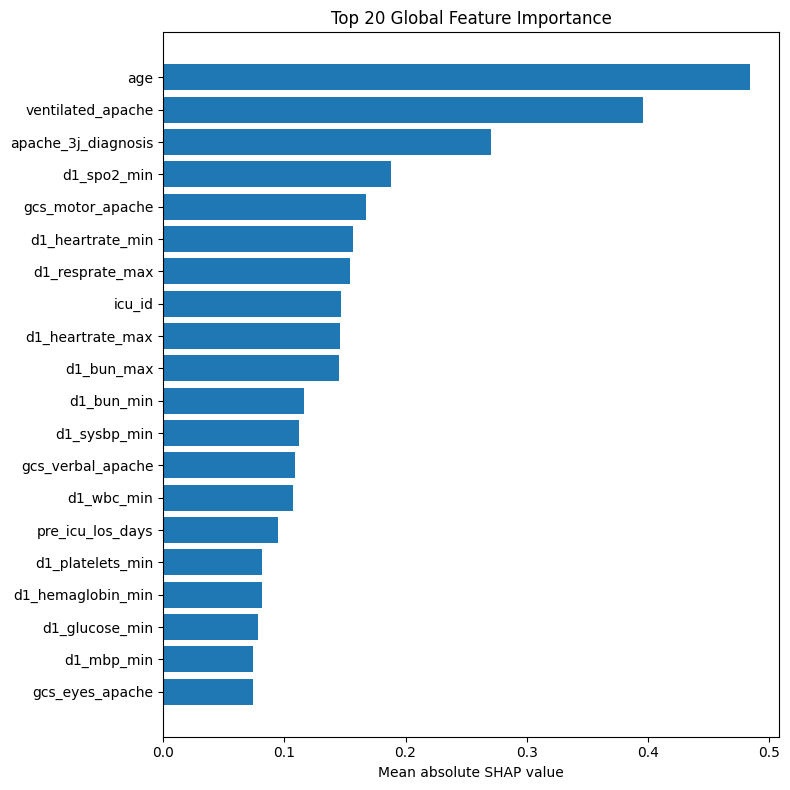

In [9]:
plt.figure(figsize=(8, 8))
top_features = shap_importance.head(20).sort_values('mean_abs_shap')

plt.barh(top_features['feature'], top_features['mean_abs_shap'])
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 Global Feature Importance')
plt.tight_layout()
plt.show()

### Note on `icu_id`

`icu_id` appears among the top global SHAP features. This variable likely represents the ICU unit/location rather than a direct clinical measurement. Therefore, it should be interpreted with caution in the explainability stage.

A future sensitivity analysis will compare model performance with and without `icu_id` to assess whether the model relies on unit-level or site-level patterns rather than purely patient-level clinical signals.

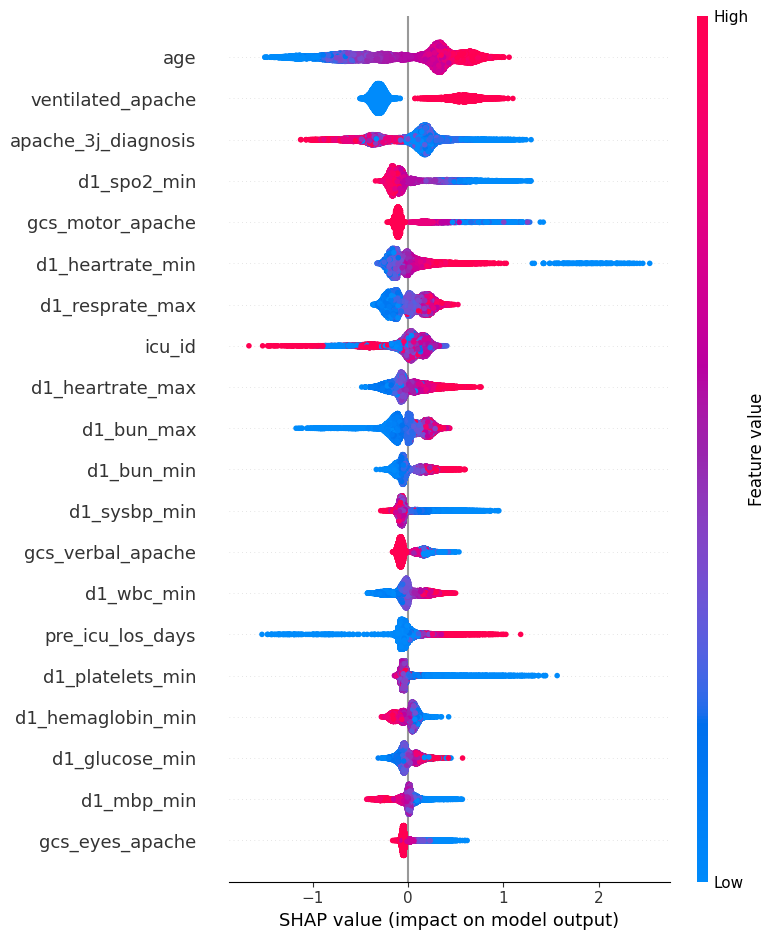

In [10]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=True
)

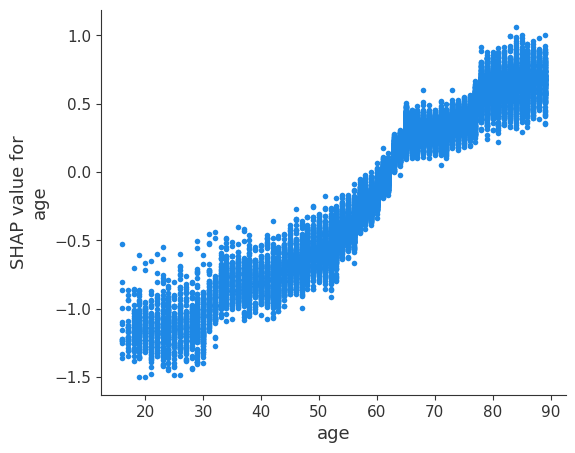

In [11]:
shap.dependence_plot(
    'age',
    shap_values,
    X_shap,
    interaction_index=None
)

In [13]:
age_shap_summary = pd.DataFrame({
    'age': X_shap['age'],
    'age_shap': shap_values[:, X_shap.columns.get_loc('age')]
})

age_shap_summary['age_group'] = pd.cut(
    age_shap_summary['age'],
    bins=[0, 40, 50, 60, 70, 80, 120],
    labels=['<=40', '41-50', '51-60', '61-70', '71-80', '80+']
)

age_shap_grouped = (
    age_shap_summary
    .groupby('age_group', observed=False)
    .agg(
        n_patients=('age', 'count'),
        mean_age=('age', 'mean'),
        mean_shap=('age_shap', 'mean'),
        median_shap=('age_shap', 'median')
    )
    .reset_index()
)

age_shap_grouped

,age_group,n_patients,mean_age,mean_shap,median_shap
0,<=40,2090,29.793780,-0.981608,-0.976090
1,41-50,1796,46.021715,-0.672068,-0.674602
2,51-60,3373,55.817670,-0.363164,-0.349500
3,61-70,4799,65.489269,0.230302,0.270387
4,71-80,3783,75.346815,0.430455,0.395909
5,80+,2502,84.476019,0.640052,0.643714


### Age SHAP Interpretation

Age shows a monotonic relationship with predicted mortality risk. Younger patients have negative SHAP contributions, while patients older than approximately 60 have positive contributions. This indicates that the model uses increasing age as a risk-increasing factor for ICU mortality.

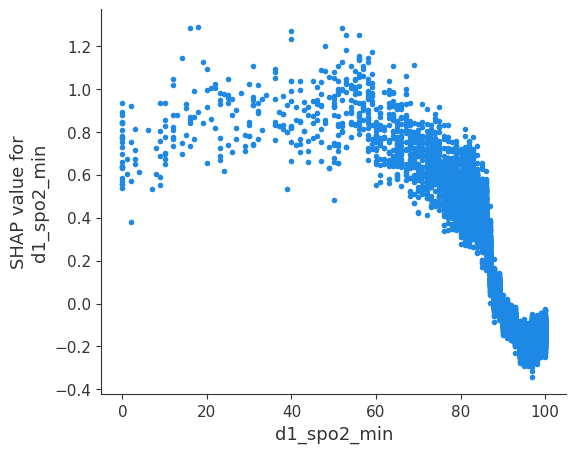

In [16]:
shap.dependence_plot(
    'd1_spo2_min',
    shap_values,
    X_shap,
    interaction_index=None
)

In [17]:
spo2_shap_summary = pd.DataFrame({
    'd1_spo2_min': X_shap['d1_spo2_min'],
    'spo2_shap': shap_values[:, X_shap.columns.get_loc('d1_spo2_min')]
})

spo2_shap_summary['spo2_group'] = pd.cut(
    spo2_shap_summary['d1_spo2_min'],
    bins=[0, 85, 90, 95, 100],
    labels=['<85', '85-90', '90-95', '95-100']
)

spo2_shap_grouped = (
    spo2_shap_summary
    .groupby('spo2_group', observed=False)
    .agg(
        n_patients=('d1_spo2_min', 'count'),
        mean_spo2=('d1_spo2_min', 'mean'),
        mean_shap=('spo2_shap', 'mean'),
        median_shap=('spo2_shap', 'median')
    )
    .reset_index()
)

spo2_shap_grouped

,spo2_group,n_patients,mean_spo2,mean_shap,median_shap
0,<85,2414,73.712510,0.577948,0.545284
1,85-90,3590,88.634540,0.061330,0.022944
2,90-95,8363,93.039699,-0.124317,-0.117508
3,95-100,3953,97.329370,-0.159847,-0.160254


### Minimum SpO2 SHAP Interpretation

The SHAP dependence plot and grouped summary show that lower minimum SpO2 values increase predicted mortality risk. Patients with `d1_spo2_min` below 85 have strongly positive SHAP contributions, while values above 90 generally have negative contributions. This indicates that the model uses low oxygen saturation as an important risk-increasing signal.

In [18]:
vent_shap_summary = pd.DataFrame({
    'ventilated_apache': X_shap['ventilated_apache'],
    'vent_shap': shap_values[:, X_shap.columns.get_loc('ventilated_apache')]
})

vent_shap_grouped = (
    vent_shap_summary
    .groupby('ventilated_apache')
    .agg(
        n_patients=('ventilated_apache', 'count'),
        mean_shap=('vent_shap', 'mean'),
        median_shap=('vent_shap', 'median')
    )
    .reset_index()
)

vent_shap_grouped

,ventilated_apache,n_patients,mean_shap,median_shap
0,0.0,12416,-0.311701,-0.310593
1,1.0,5927,0.572688,0.578618


/var/folders/8q/6ppn3sn52s37836ffh2298v40000gn/T/ipykernel_17754/1300082300.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


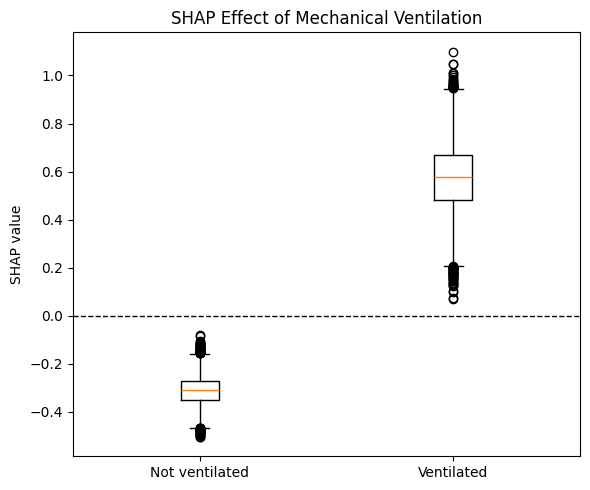

In [19]:
plt.figure(figsize=(6, 5))
plt.boxplot(
    [
        vent_shap_summary.loc[vent_shap_summary['ventilated_apache'] == 0, 'vent_shap'],
        vent_shap_summary.loc[vent_shap_summary['ventilated_apache'] == 1, 'vent_shap']
    ],
    labels=['Not ventilated', 'Ventilated']
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('SHAP value')
plt.title('SHAP Effect of Mechanical Ventilation')
plt.tight_layout()
plt.show()

### Mechanical Ventilation SHAP Interpretation

`ventilated_apache` shows a clear separation in SHAP contributions. Patients who were not ventilated had negative SHAP values, indicating reduced predicted mortality risk. In contrast, ventilated patients had strongly positive SHAP values, suggesting that the model uses mechanical ventilation as an important risk-increasing signal. This is clinically plausible because ventilation is often associated with more severe respiratory failure or critical illness.

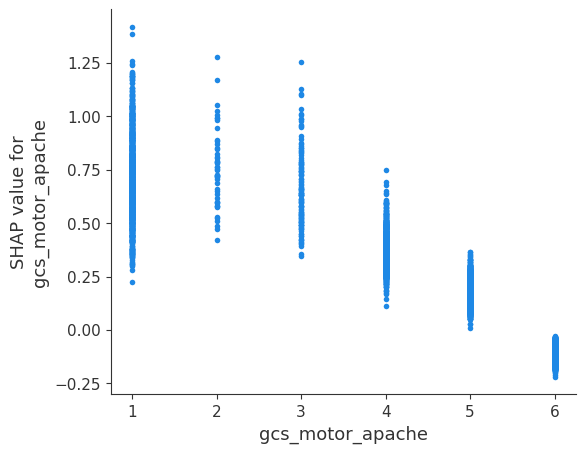

In [20]:
shap.dependence_plot(
    'gcs_motor_apache',
    shap_values,
    X_shap,
    interaction_index=None
)

In [21]:
gcs_motor_shap_summary = pd.DataFrame({
    'gcs_motor_apache': X_shap['gcs_motor_apache'],
    'gcs_motor_shap': shap_values[:, X_shap.columns.get_loc('gcs_motor_apache')]
})

gcs_motor_shap_grouped = (
    gcs_motor_shap_summary
    .groupby('gcs_motor_apache')
    .agg(
        n_patients=('gcs_motor_apache', 'count'),
        mean_shap=('gcs_motor_shap', 'mean'),
        median_shap=('gcs_motor_shap', 'median')
    )
    .reset_index()
    .sort_values('gcs_motor_apache')
)

gcs_motor_shap_grouped

,gcs_motor_apache,n_patients,mean_shap,median_shap
0,1.0,1088,0.717160,0.704936
1,2.0,48,0.758464,0.750309
2,3.0,117,0.667540,0.638819
3,4.0,913,0.372023,0.365268
4,5.0,1563,0.177056,0.175536
5,6.0,14614,-0.106819,-0.105911


### GCS Motor SHAP Interpretation

`gcs_motor_apache` shows a clear inverse relationship with predicted mortality risk. Lower motor scores have strongly positive SHAP contributions, indicating increased mortality risk, while the highest motor score has a negative SHAP contribution. This suggests that the model uses impaired motor response as an important risk-increasing signal, which is clinically consistent with neurological severity.

In [24]:
prediction_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba': y_proba,
    'y_pred': y_pred
})

prediction_df['prediction_type'] = np.select(
    [
        (prediction_df['y_true'] == 1) & (prediction_df['y_pred'] == 1),
        (prediction_df['y_true'] == 1) & (prediction_df['y_pred'] == 0),
        (prediction_df['y_true'] == 0) & (prediction_df['y_pred'] == 1),
        (prediction_df['y_true'] == 0) & (prediction_df['y_pred'] == 0),
    ],
    ['TP', 'FN', 'FP', 'TN'],
    default='Unknown'
)

prediction_df['prediction_type'].value_counts()

prediction_type
TN    15537
FP     1223
TP      995
FN      588
Name: count, dtype: int64

In [25]:
tp_idx = (
    prediction_df[prediction_df['prediction_type'] == 'TP']
    .sort_values('y_proba', ascending=False)
    .index[0]
)

tp_idx, prediction_df.loc[tp_idx]

(np.int64(14271),
 y_true                    1
 y_proba            0.999529
 y_pred                    1
 prediction_type          TP
 Name: 14271, dtype: object)

In [26]:
def explain_patient(index, X, shap_values, prediction_df, top_n=10):
    patient_shap = pd.DataFrame({
        'feature': X.columns,
        'value': X.iloc[index].values,
        'shap_value': shap_values[index]
    })

    patient_shap['abs_shap'] = patient_shap['shap_value'].abs()

    print('Prediction info:')
    display(prediction_df.loc[index])

    print('\nTop risk-increasing features:')
    display(
        patient_shap
        .sort_values('shap_value', ascending=False)
        .head(top_n)
        [['feature', 'value', 'shap_value']]
    )

    print('\nTop risk-decreasing features:')
    display(
        patient_shap
        .sort_values('shap_value', ascending=True)
        .head(top_n)
        [['feature', 'value', 'shap_value']]
    )

    return patient_shap.sort_values('abs_shap', ascending=False)

tp_explanation = explain_patient(
    tp_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    1
y_proba            0.999529
y_pred                    1
prediction_type          TP
Name: 14271, dtype: object


Top risk-increasing features:


,feature,value,shap_value
33,d1_heartrate_min,0.0,2.004644
41,d1_spo2_min,31.0,0.948756
26,ventilated_apache,1.0,0.725048
76,d1_hco3_max,12.0,0.721857
43,d1_sysbp_min,41.0,0.721031
15,gcs_motor_apache,1.0,0.564184
77,d1_hco3_min,8.0,0.377669
83,d1_platelets_min,58.0,0.344773
40,d1_spo2_max,95.0,0.256833
35,d1_mbp_min,39.0,0.247266



Top risk-decreasing features:


,feature,value,shap_value
89,d1_wbc_min,1.1,-0.117466
68,d1_bun_max,18.0,-0.070402
81,d1_hematocrit_min,19.5,-0.047929
54,h1_mbp_max,122.0,-0.044445
28,d1_diasbp_max,108.0,-0.043048
20,hematocrit_apache,19.5,-0.041927
1,bmi,33.258301,-0.040573
3,height,154.9,-0.039523
30,d1_diasbp_noninvasive_max,108.0,-0.036790
67,h1_temp_min,37.1,-0.031879


In [31]:
(X_test['d1_heartrate_min'] == 0).sum()

np.int64(129)

In [32]:
hr_zero_mask = X_test['d1_heartrate_min'] == 0

print(f'Patients with d1_heartrate_min = 0: {hr_zero_mask.sum()}')
print(f'Death rate when d1_heartrate_min = 0: {y_test[hr_zero_mask].mean():.3f}')
print(f'Death rate when d1_heartrate_min > 0: {y_test[~hr_zero_mask].mean():.3f}')

Patients with d1_heartrate_min = 0: 129
Death rate when d1_heartrate_min = 0: 0.651
Death rate when d1_heartrate_min > 0: 0.082


In [33]:
hr_min = X_shap['d1_heartrate_min']

print(f'Sıfır olan hasta sayısı: {(hr_min == 0).sum()}')
print(f'Toplam hasta: {len(hr_min)}')
print(f'Oran: {(hr_min == 0).mean():.3f}')
print()
print(hr_min.describe())


Sıfır olan hasta sayısı: 129
Toplam hasta: 18343
Oran: 0.007

count    18343.000000
mean        70.180287
std         17.260900
min          0.000000
25%         60.000000
50%         69.000000
75%         80.000000
max        155.000000
Name: d1_heartrate_min, dtype: float64


### Note on `d1_heartrate_min = 0`

In the local true positive explanation, `d1_heartrate_min = 0` had the largest positive SHAP contribution. This value is physiologically extreme and may represent a true critical event such as cardiac arrest or peri-arrest, but it may also reflect a recording artifact or data quality issue.

In the test set, 129 patients (0.7%) had `d1_heartrate_min = 0`. Their observed mortality rate was 65.1%, compared with 8.2% among patients with `d1_heartrate_min > 0`. Because this rare value is strongly associated with mortality, it was retained for the current analysis but should be interpreted with caution. A future sensitivity analysis should evaluate model behavior after treating physiologically implausible zero vital signs as missing or outlier values.

In [34]:
fn_idx = (
    prediction_df[prediction_df['prediction_type'] == 'FN']
    .sort_values('y_proba', ascending=True)
    .index[0]
)

fn_idx, prediction_df.loc[fn_idx]

(np.int64(1405),
 y_true                   1
 y_proba            0.00372
 y_pred                   0
 prediction_type         FN
 Name: 1405, dtype: object)

In [35]:
fn_explanation = explain_patient(
    fn_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                   1
y_proba            0.00372
y_pred                   0
prediction_type         FN
Name: 1405, dtype: object


Top risk-increasing features:


,feature,value,shap_value
0,age,72.0,0.304992
38,d1_resprate_max,56.0,0.182868
9,apache_3j_diagnosis,111.01,0.115516
29,d1_diasbp_min,27.0,0.110244
22,map_apache,166.0,0.100940
36,d1_mbp_noninvasive_max,166.0,0.082677
58,h1_resprate_max,29.0,0.050001
31,d1_diasbp_noninvasive_min,27.0,0.042921
245,apache_3j_bodysystem_Metabolic,False,0.036129
53,h1_heartrate_min,57.0,0.035293



Top risk-decreasing features:


,feature,value,shap_value
26,ventilated_apache,0.0,-0.346156
89,d1_wbc_min,6.0,-0.335444
4,icu_id,895,-0.318022
59,h1_resprate_min,0.0,-0.274040
33,d1_heartrate_min,56.0,-0.223182
75,d1_glucose_min,73.0,-0.167003
55,h1_mbp_min,104.0,-0.139081
68,d1_bun_max,17.0,-0.130251
32,d1_heartrate_max,91.0,-0.124807
57,h1_mbp_noninvasive_min,104.0,-0.123728


In [36]:
(X_test['h1_resprate_min'] == 0).sum()

np.int64(147)

In [37]:
rr_zero_mask = X_test['h1_resprate_min'] == 0

print(f'Patients with h1_resprate_min = 0: {rr_zero_mask.sum()}')
print(f'Death rate when h1_resprate_min = 0: {y_test[rr_zero_mask].mean():.3f}')
print(f'Death rate when h1_resprate_min > 0: {y_test[~rr_zero_mask].mean():.3f}')

Patients with h1_resprate_min = 0: 147
Death rate when h1_resprate_min = 0: 0.129
Death rate when h1_resprate_min > 0: 0.086


### Error Analysis Note — False Negative Case

The selected false negative case corresponds to a patient who died but was assigned a very low predicted mortality probability by the model. The local SHAP explanation shows that some factors increased the predicted risk, including older age, high maximum respiratory rate, low diastolic blood pressure, and diagnosis-related information. However, several features pushed the prediction strongly toward survival, such as absence of mechanical ventilation, normal WBC, relatively non-extreme heart rate values, low/normal BUN, and higher early mean blood pressure values.

This case suggests that the model may miss mortality cases when classical high-risk indicators are not strongly present. The explanation also includes variables that require cautious interpretation, such as `icu_id` and zero-valued vital signs. These observations will be revisited in future sensitivity analyses.

In [38]:
fp_idx = (
    prediction_df[prediction_df['prediction_type'] == 'FP']
    .sort_values('y_proba', ascending=False)
    .index[0]
)

fp_idx, prediction_df.loc[fp_idx]

(np.int64(10840),
 y_true                    0
 y_proba            0.995382
 y_pred                    1
 prediction_type          FP
 Name: 10840, dtype: object)

In [39]:
fp_explanation = explain_patient(
    fp_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    0
y_proba            0.995382
y_pred                    1
prediction_type          FP
Name: 10840, dtype: object


Top risk-increasing features:


,feature,value,shap_value
33,d1_heartrate_min,0.0,2.115243
0,age,84.0,0.682460
43,d1_sysbp_min,61.0,0.607199
40,d1_spo2_max,90.0,0.416094
15,gcs_motor_apache,4.0,0.370608
46,d1_temp_max,35.9,0.329996
39,d1_resprate_min,0.0,0.235624
17,gcs_verbal_apache,1.0,0.229507
76,d1_hco3_max,17.0,0.214141
77,d1_hco3_min,17.0,0.200580



Top risk-decreasing features:


,feature,value,shap_value
26,ventilated_apache,0.0,-0.262856
30,d1_diasbp_noninvasive_max,46.0,-0.183319
38,d1_resprate_max,24.0,-0.113011
50,h1_diasbp_noninvasive_max,43.0,-0.112461
41,d1_spo2_min,90.0,-0.106005
92,diabetes_mellitus,1.0,-0.075091
14,gcs_eyes_apache,4.0,-0.051885
23,resprate_apache,12.0,-0.050309
5,pre_icu_los_days,0.175,-0.045505
237,icu_type_Med-Surg ICU,True,-0.038518


### Local Explanation — False Positive Case

This false positive case corresponds to a patient who survived (`y_true = 0`) but received a very high predicted mortality probability (`p = 0.9954`). The strongest risk-increasing features included `d1_heartrate_min = 0`, advanced age, low systolic blood pressure, low maximum SpO2, impaired GCS motor and verbal scores, low body temperature, low respiratory rate, and low bicarbonate values.

Although the patient survived, the model's high-risk prediction is clinically understandable because several features suggested severe physiological instability. This case may represent a patient who had strong early risk signals but survived due to clinical intervention, recovery, or transient instability. It also reinforces the need to interpret zero-valued vital signs cautiously, since both `d1_heartrate_min = 0` and `d1_resprate_min = 0` contributed to the high-risk prediction.

In [40]:
tn_idx = (
    prediction_df[prediction_df['prediction_type'] == 'TN']
    .sort_values('y_proba', ascending=True)
    .index[0]
)

tn_idx, prediction_df.loc[tn_idx]

(np.int64(15497),
 y_true                    0
 y_proba            0.000199
 y_pred                    0
 prediction_type          TN
 Name: 15497, dtype: object)

In [41]:
tn_explanation = explain_patient(
    tn_idx,
    X_shap,
    shap_values,
    prediction_df,
    top_n=10
)

Prediction info:


y_true                    0
y_proba            0.000199
y_pred                    0
prediction_type          TN
Name: 15497, dtype: object


Top risk-increasing features:


,feature,value,shap_value
46,d1_temp_max,38.3,0.155156
84,d1_potassium_max,3.3,0.045555
31,d1_diasbp_noninvasive_min,59.0,0.027760
53,h1_heartrate_min,82.0,0.025042
49,h1_diasbp_min,59.0,0.023857
240,apache_3j_bodysystem_Cardiovascular,False,0.021761
13,creatinine_apache,0.84,0.021435
36,d1_mbp_noninvasive_max,126.0,0.019126
197,ethnicity_African American,False,0.015418
85,d1_potassium_min,3.3,0.014933



Top risk-decreasing features:


,feature,value,shap_value
5,pre_icu_los_days,-0.109722,-0.832773
4,icu_id,91,-0.705732
0,age,46.0,-0.619559
245,apache_3j_bodysystem_Metabolic,True,-0.338697
9,apache_3j_diagnosis,703.03,-0.320654
26,ventilated_apache,0.0,-0.242347
35,d1_mbp_min,86.0,-0.241259
38,d1_resprate_max,20.0,-0.205492
255,apache_2_bodysystem_Metabolic,True,-0.186616
33,d1_heartrate_min,60.0,-0.160251


### Local Explanation — True Negative Case

This true negative case corresponds to a patient who survived and received a very low predicted mortality probability (`p = 0.0002`). The strongest risk-decreasing signals included younger age, absence of mechanical ventilation, stable mean blood pressure, non-extreme respiratory rate, normal minimum heart rate, and diagnosis-related information. These factors are clinically consistent with a lower-risk ICU profile.

However, the local explanation also shows strong negative contributions from `icu_id` and `pre_icu_los_days`. Since `icu_id` is not a direct clinical measurement and `pre_icu_los_days` can contain negative values, these variables should be interpreted cautiously and may require future sensitivity or data quality analysis.

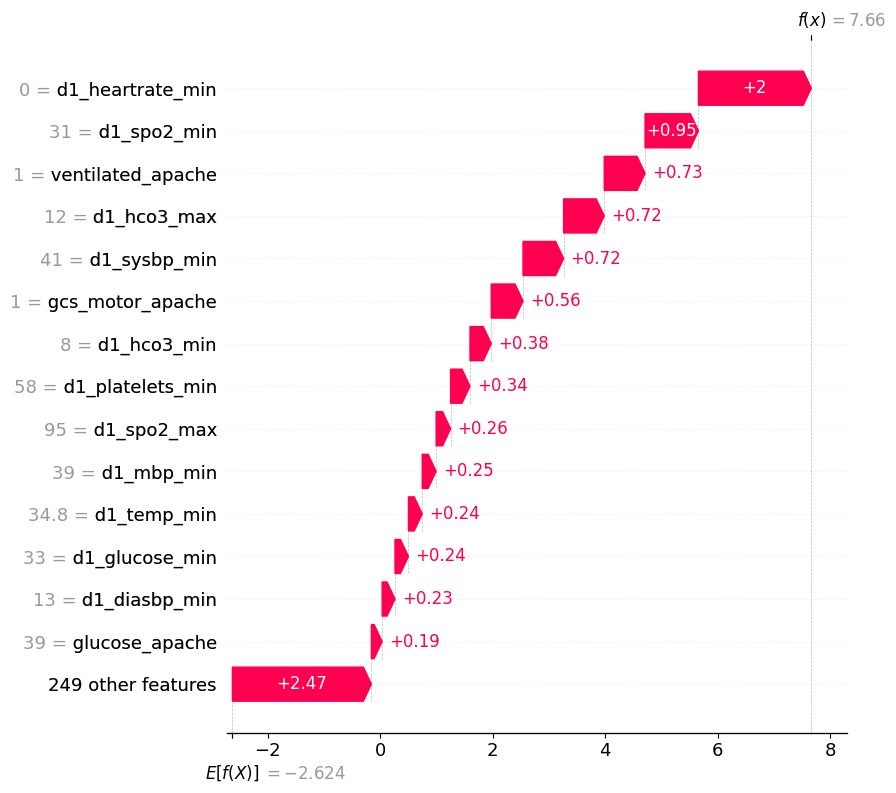

In [42]:
expected_value = explainer.expected_value

if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[tp_idx],
        base_values=expected_value,
        data=X_shap.iloc[tp_idx],
        feature_names=X_shap.columns
    ),
    max_display=15
)

In [43]:
def plot_patient_waterfall(index, title=None, max_display=15):
    expected_value = explainer.expected_value

    if isinstance(expected_value, list):
        expected_value = expected_value[1]

    if title is not None:
        print(title)

    display(prediction_df.loc[index])

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index],
            base_values=expected_value,
            data=X_shap.iloc[index],
            feature_names=X_shap.columns
        ),
        max_display=max_display
    )

True Positive Patient


y_true                    1
y_proba            0.999529
y_pred                    1
prediction_type          TP
Name: 14271, dtype: object

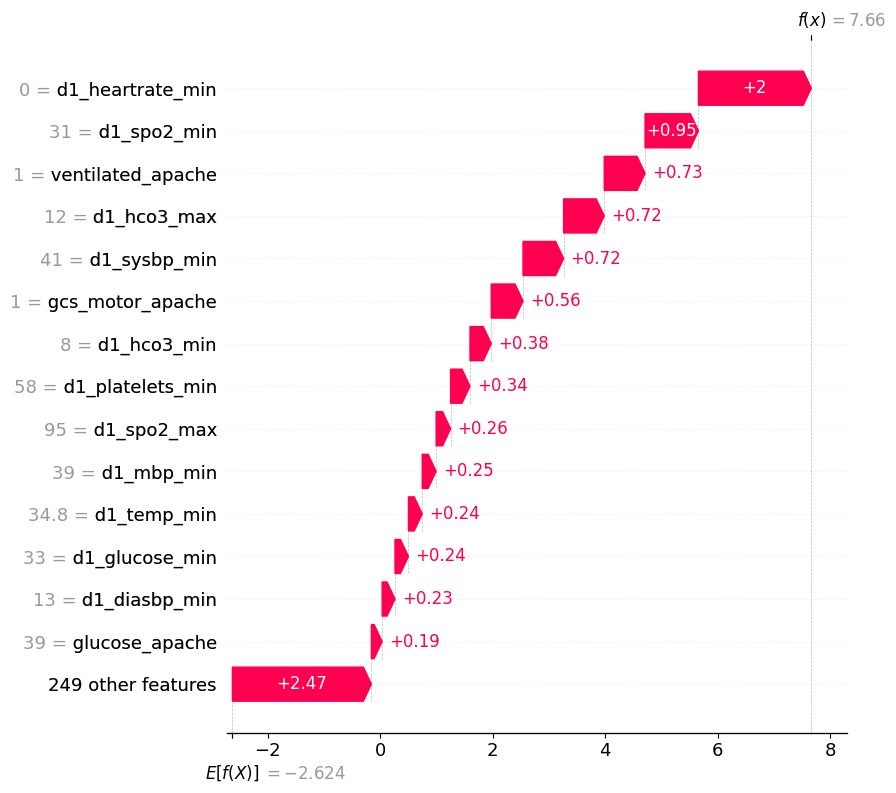

False Negative Patient


y_true                   1
y_proba            0.00372
y_pred                   0
prediction_type         FN
Name: 1405, dtype: object

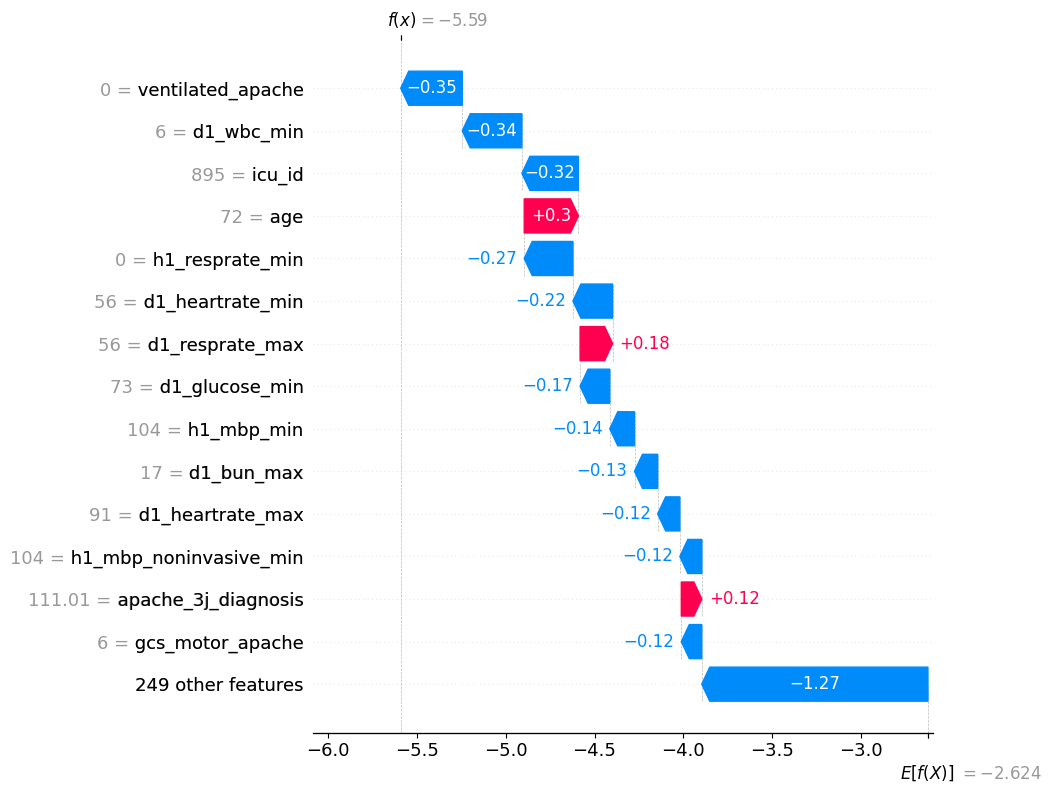

False Positive Patient


y_true                    0
y_proba            0.995382
y_pred                    1
prediction_type          FP
Name: 10840, dtype: object

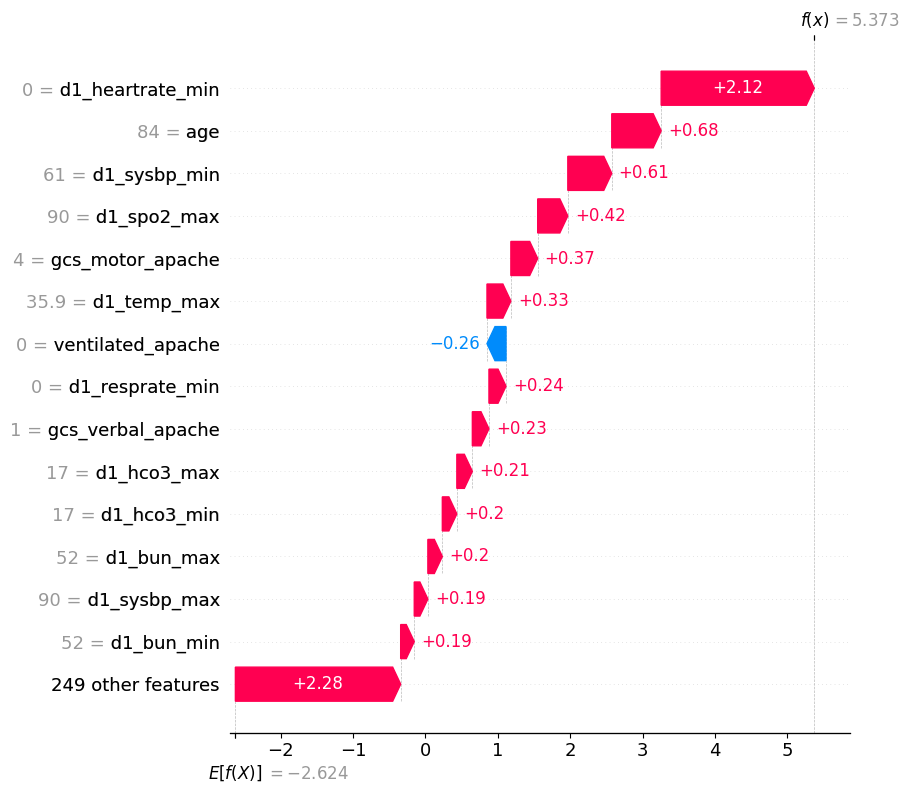

True Negative Patient


y_true                    0
y_proba            0.000199
y_pred                    0
prediction_type          TN
Name: 15497, dtype: object

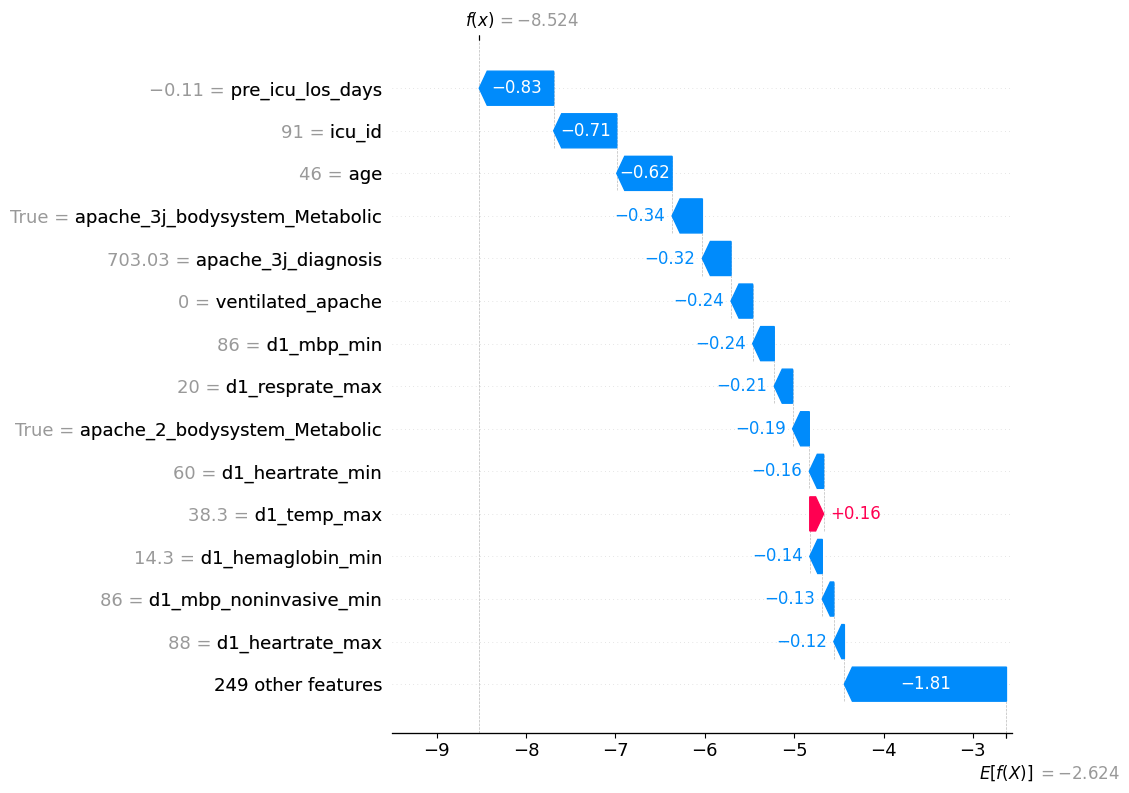

In [44]:
plot_patient_waterfall(tp_idx, title='True Positive Patient')
plot_patient_waterfall(fn_idx, title='False Negative Patient')
plot_patient_waterfall(fp_idx, title='False Positive Patient')
plot_patient_waterfall(tn_idx, title='True Negative Patient')

In [45]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns)
shap_df['prediction_type'] = prediction_df['prediction_type'].values

group_mean_shap = (
    shap_df
    .groupby('prediction_type')
    .mean()
)

group_mean_abs_shap = (
    shap_df
    .drop(columns='prediction_type')
    .abs()
    .assign(prediction_type=prediction_df['prediction_type'].values)
    .groupby('prediction_type')
    .mean()
)

In [46]:
def top_group_shap(group_name, n=10):
    mean_shap = group_mean_shap.loc[group_name].sort_values(ascending=False)
    mean_abs_shap = group_mean_abs_shap.loc[group_name].sort_values(ascending=False)

    print(f'=== {group_name} — Top Mean Positive SHAP ===')
    display(mean_shap.head(n).reset_index().rename(columns={'index': 'feature', group_name: 'mean_shap'}))

    print(f'=== {group_name} — Top Mean Absolute SHAP ===')
    display(mean_abs_shap.head(n).reset_index().rename(columns={'index': 'feature', group_name: 'mean_abs_shap'}))

In [47]:
for group in ['TP', 'FN', 'FP', 'TN']:
    top_group_shap(group, n=10)

=== TP — Top Mean Positive SHAP ===


,feature,mean_shap
0,ventilated_apache,0.478262
1,gcs_motor_apache,0.332045
2,apache_3j_diagnosis,0.317351
3,d1_spo2_min,0.254991
4,d1_heartrate_min,0.226457
5,d1_sysbp_min,0.197452
6,age,0.189925
7,gcs_eyes_apache,0.130107
8,d1_heartrate_max,0.128385
9,d1_bun_max,0.121614


=== TP — Top Mean Absolute SHAP ===


,feature,mean_abs_shap
0,ventilated_apache,0.579737
1,gcs_motor_apache,0.400841
2,age,0.387333
3,apache_3j_diagnosis,0.361696
4,d1_spo2_min,0.356702
5,d1_heartrate_min,0.306212
6,d1_sysbp_min,0.241724
7,d1_heartrate_max,0.183298
8,d1_temp_min,0.161451
9,gcs_eyes_apache,0.160961


=== FN — Top Mean Positive SHAP ===


...

,feature,mean_abs_shap
0,ventilated_apache,0.530576
1,age,0.420647
2,d1_spo2_min,0.295969
3,gcs_motor_apache,0.288035
4,apache_3j_diagnosis,0.276890
5,d1_heartrate_min,0.198871
6,d1_sysbp_min,0.187791
7,d1_heartrate_max,0.183420
8,d1_bun_max,0.171179
9,d1_resprate_max,0.152598


=== TN — Top Mean Positive SHAP ===


,feature,mean_shap
0,d1_hematocrit_max,0.006108
1,d1_sodium_max_missing,0.005860
2,d1_hematocrit_min,0.005435
3,h1_heartrate_max,0.004469
4,glucose_apache,0.004104
5,h1_diasbp_min,0.003374
6,h1_sysbp_noninvasive_max,0.003020
7,h1_diasbp_max,0.002818
8,d1_spo2_max,0.002442
9,d1_creatinine_min,0.002432


=== TN — Top Mean Absolute SHAP ===


,feature,mean_abs_shap
0,age,0.496456
1,ventilated_apache,0.372183
2,apache_3j_diagnosis,0.264987
3,d1_spo2_min,0.167661
4,d1_resprate_max,0.155700
5,icu_id,0.148240
6,d1_heartrate_min,0.143284
7,gcs_motor_apache,0.142123
8,d1_bun_max,0.141586
9,d1_heartrate_max,0.140034


In [48]:
import os

os.makedirs('../reports/explainability', exist_ok=True)

shap_importance.to_csv(
    '../reports/explainability/global_shap_importance.csv',
    index=False
)

prediction_df.to_csv(
    '../reports/explainability/prediction_types.csv',
    index=False
)

tp_explanation.to_csv(
    '../reports/explainability/local_explanation_tp.csv',
    index=False
)

fn_explanation.to_csv(
    '../reports/explainability/local_explanation_fn.csv',
    index=False
)

fp_explanation.to_csv(
    '../reports/explainability/local_explanation_fp.csv',
    index=False
)

tn_explanation.to_csv(
    '../reports/explainability/local_explanation_tn.csv',
    index=False
)

group_mean_shap.to_csv(
    '../reports/explainability/group_mean_shap.csv'
)

group_mean_abs_shap.to_csv(
    '../reports/explainability/group_mean_abs_shap.csv'
)

print('Explainability outputs saved.')

Explainability outputs saved.


## Explainability Summary

This notebook analyzed the final LightGBM model using SHAP on the full test set. Global SHAP analysis showed that the model relied on clinically meaningful features such as age, mechanical ventilation, diagnosis information, minimum SpO2, GCS motor score, vital signs, and laboratory values.

Feature-level analyses showed that older age, low minimum SpO2, mechanical ventilation, and impaired GCS motor response increased predicted mortality risk in clinically plausible directions. Local explanations for TP, FN, FP, and TN cases showed how the model behaves across correct predictions and error cases.

The error analysis suggested that false positives often resemble high-risk true positives, while false negatives may occur when classical high-risk signals are weaker or outweighed by survival-associated features. Several variables require cautious interpretation in future work, including `icu_id`, zero-valued vital signs, and negative `pre_icu_los_days`.

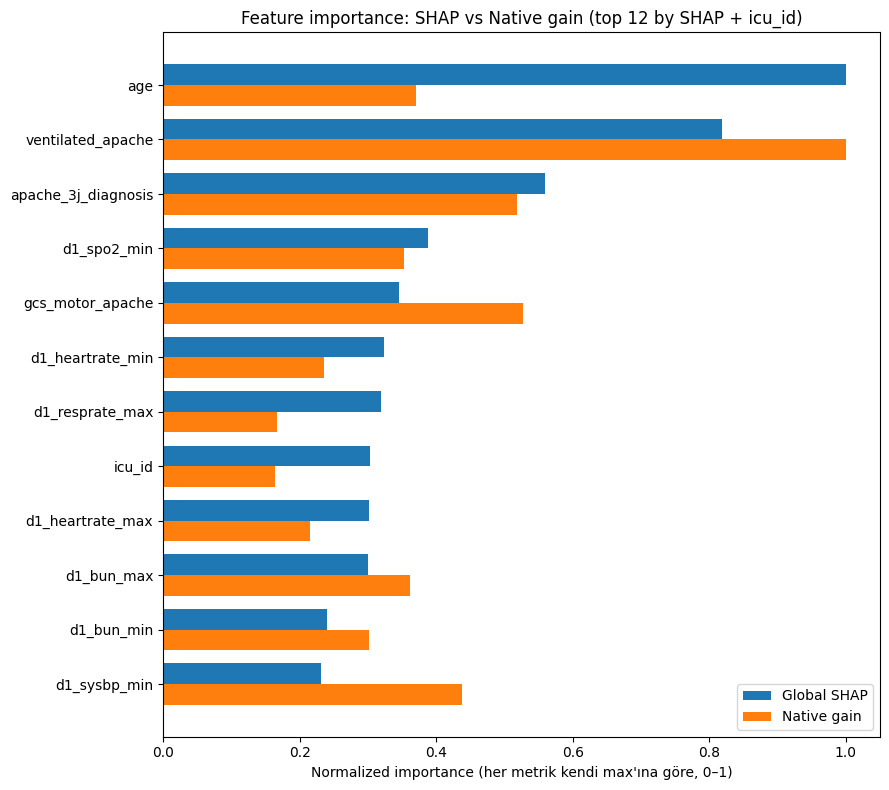

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Top 12 feature (SHAP'a göre) + icu_id garanti dahil
top = comp.sort_values("rank_shap").head(12)
if "icu_id" not in top["feature"].values:
    top = pd.concat([top, comp[comp["feature"] == "icu_id"]])
top = top.copy()

# Her metriği kendi max'ına göre 0-1'e normalize et (ölçekler farklı)
top["shap_norm"] = top["mean_abs_shap"] / comp["mean_abs_shap"].max()
top["gain_norm"] = top["native_gain"]   / comp["native_gain"].max()

# Yukarıdan aşağıya SHAP sırası dursun diye ters çevir
top = top.sort_values("rank_shap").iloc[::-1]

y = np.arange(len(top))
h = 0.38

plt.figure(figsize=(9, 8))
plt.barh(y + h/2, top["shap_norm"], height=h, label="Global SHAP")
plt.barh(y - h/2, top["gain_norm"], height=h, label="Native gain")

plt.yticks(y, top["feature"])
plt.xlabel("Normalized importance (her metrik kendi max'ına göre, 0–1)")
plt.title("Feature importance: SHAP vs Native gain (top 12 by SHAP + icu_id)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
from pathlib import Path
import itertools
import re
import pandas as pd

explainability_dir = Path("../reports/02_explainability")
dependence_dir = explainability_dir / "top20_dependence_plots"
dependence_dir.mkdir(parents=True, exist_ok=True)

try:
    shap_importance
except NameError:
    shap_importance = pd.read_csv(
        explainability_dir / "global_shap_importance.csv"
    )

top20_features = shap_importance.head(20)["feature"].tolist()

top20_features_df = shap_importance.head(20).reset_index(drop=True)
top20_features_df["rank"] = top20_features_df.index + 1
top20_features_df = top20_features_df[["rank", "feature", "mean_abs_shap"]]

top20_features_df.to_csv(
    explainability_dir / "top20_shap_features.csv",
    index=False
)

top20_features_df

,rank,feature,mean_abs_shap
0,1,age,0.484075
1,2,ventilated_apache,0.396031
2,3,apache_3j_diagnosis,0.270461
3,4,d1_spo2_min,0.188095
4,5,gcs_motor_apache,0.167488
5,6,d1_heartrate_min,0.156364
6,7,d1_resprate_max,0.154597
7,8,icu_id,0.146550
8,9,d1_heartrate_max,0.145811
9,10,d1_bun_max,0.145123


In [4]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path

explainability_dir = Path("../reports/02_explainability")
dependence_dir = explainability_dir / "top20_dependence_plots"
dependence_dir.mkdir(parents=True, exist_ok=True)

try:
    X_shap
except NameError:
    X_test = pd.read_csv("../data/processed/X_test.csv")
    X_shap = X_test.copy()

try:
    final_model
except NameError:
    final_model = joblib.load("../models/lgbm_tuned_clean.pkl")

try:
    explainer
except NameError:
    explainer = shap.TreeExplainer(final_model)

try:
    shap_values
except NameError:
    shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

try:
    shap_importance
except NameError:
    shap_importance = pd.read_csv(
        explainability_dir / "global_shap_importance.csv"
    )

try:
    top20_features
except NameError:
    top20_features = shap_importance.head(20)["feature"].tolist()

print("X_shap shape:", X_shap.shape)
print("shap_values shape:", shap_values.shape)
print("Top 20 features:", top20_features)

X_shap shape: (18343, 263)
shap_values shape: (18343, 263)
Top 20 features: ['age', 'ventilated_apache', 'apache_3j_diagnosis', 'd1_spo2_min', 'gcs_motor_apache', 'd1_heartrate_min', 'd1_resprate_max', 'icu_id', 'd1_heartrate_max', 'd1_bun_max', 'd1_bun_min', 'd1_sysbp_min', 'gcs_verbal_apache', 'd1_wbc_min', 'pre_icu_los_days', 'd1_platelets_min', 'd1_hemaglobin_min', 'd1_glucose_min', 'd1_mbp_min', 'gcs_eyes_apache']


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [5]:
interaction_sample_size = min(300, len(X_shap))

X_interaction_sample = X_shap.sample(
    n=interaction_sample_size,
    random_state=42
)

interaction_values = explainer.shap_interaction_values(X_interaction_sample)

if isinstance(interaction_values, list):
    interaction_values = interaction_values[1]

print(f"Interaction sample shape: {X_interaction_sample.shape}")
print(f"Interaction values shape: {interaction_values.shape}")

Interaction sample shape: (300, 263)
Interaction values shape: (300, 263, 263)


In [6]:
top20_indices = [X_shap.columns.get_loc(feature) for feature in top20_features]

top20_interaction_values = interaction_values[:, top20_indices, :][:, :, top20_indices]

mean_abs_interaction_matrix = np.abs(top20_interaction_values).mean(axis=0)

# Diagonal main effect olduğu için pairwise interaction sıralamasında sıfırlıyoruz.
np.fill_diagonal(mean_abs_interaction_matrix, 0)

interaction_matrix_df = pd.DataFrame(
    mean_abs_interaction_matrix,
    index=top20_features,
    columns=top20_features
)

interaction_matrix_df.to_csv(
    explainability_dir / "top20_shap_interaction_matrix.csv"
)

interaction_matrix_df

,age,ventilated_apache,apache_3j_diagnosis,d1_spo2_min,gcs_motor_apache,d1_heartrate_min,d1_resprate_max,icu_id,d1_heartrate_max,d1_bun_max,d1_bun_min,d1_sysbp_min,gcs_verbal_apache,d1_wbc_min,pre_icu_los_days,d1_platelets_min,d1_hemaglobin_min,d1_glucose_min,d1_mbp_min,gcs_eyes_apache
age,0.000000,0.018173,0.009639,0.006136,0.012252,0.012452,0.014431,0.007321,0.007295,0.006094,0.008233,0.007872,0.005103,0.008372,0.006862,0.011637,0.004285,0.002932,0.004088,0.005367
ventilated_apache,0.018173,0.000000,0.020768,0.009197,0.010689,0.008407,0.015892,0.005207,0.005361,0.008313,0.013593,0.008231,0.015258,0.003117,0.006902,0.003755,0.002204,0.001961,0.004392,0.005529
apache_3j_diagnosis,0.009639,0.020768,0.000000,0.008032,0.009275,0.004168,0.004101,0.005126,0.008006,0.004618,0.005206,0.004949,0.006644,0.003878,0.006002,0.005221,0.003859,0.004102,0.004784,0.002910
d1_spo2_min,0.006136,0.009197,0.008032,0.000000,0.004364,0.005375,0.002476,0.005567,0.005107,0.004652,0.003471,0.006737,0.003178,0.001948,0.002418,0.004829,0.001259,0.003108,0.002845,0.002526
gcs_motor_apache,0.012252,0.010689,0.009275,0.004364,0.000000,0.002737,0.003386,0.001319,0.004985,0.007426,0.006264,0.005152,0.002534,0.002211,0.005566,0.001788,0.001595,0.004125,0.002310,0.004592
d1_heartrate_min,0.012452,0.008407,0.004168,0.005375,0.002737,0.000000,0.003848,0.005454,0.003699,0.002838,0.003407,0.003263,0.004259,0.004552,0.003602,0.002120,0.002241,0.002116,0.001744,0.001804
d1_resprate_max,0.014431,0.015892,0.004101,0.002476,0.003386,0.003848,0.000000,0.005868,0.004856,0.007603,0.005430,0.002503,0.003086,0.003415,0.003376,0.003100,0.004678,0.002218,0.001380,0.000763
icu_id,0.007321,0.005207,0.005126,0.005567,0.001319,0.005454,0.005868,0.000000,0.006472,0.002008,0.001561,0.002504,0.001366,0.007645,0.006273,0.003461,0.002136,0.003523,0.003457,0.001218
d1_heartrate_max,0.007295,0.005361,0.008006,0.005107,0.004985,0.003699,0.004856,0.006472,0.000000,0.004175,0.002843,0.003415,0.004238,0.002050,0.006187,0.003206,0.002534,0.002091,0.002350,0.001611
d1_bun_max,0.006094,0.008313,0.004618,0.004652,0.007426,0.002838,0.007603,0.002008,0.004175,0.000000,0.002259,0.005388,0.003043,0.002663,0.004486,0.002848,0.005139,0.002033,0.002142,0.003046


In [8]:
interaction_rows = []

for i, j in itertools.combinations(range(len(top20_features)), 2):
    feature_1 = top20_features[i]
    feature_2 = top20_features[j]

    pair_values = top20_interaction_values[:, i, j]

    interaction_rows.append({
        "feature_1": feature_1,
        "feature_2": feature_2,
        "mean_abs_interaction": np.abs(pair_values).mean(),
        "mean_signed_interaction": pair_values.mean(),
        "median_signed_interaction": np.median(pair_values),
    })

top_interactions = (
    pd.DataFrame(interaction_rows)
    .sort_values("mean_abs_interaction", ascending=False)
    .reset_index(drop=True)
)

top_interactions["rank"] = top_interactions.index + 1

top_interactions = top_interactions[
    [
        "rank",
        "feature_1",
        "feature_2",
        "mean_abs_interaction",
        "mean_signed_interaction",
        "median_signed_interaction",
    ]
]

top_interactions.to_csv(
    explainability_dir / "top20_shap_interactions.csv",
    index=False
)

top_interactions.head(20)

,rank,feature_1,feature_2,mean_abs_interaction,mean_signed_interaction,median_signed_interaction
0,1,ventilated_apache,apache_3j_diagnosis,0.020768,-0.003861,-0.003990
1,2,age,ventilated_apache,0.018173,0.000412,0.000043
2,3,ventilated_apache,d1_resprate_max,0.015892,-0.002425,-0.004912
3,4,ventilated_apache,gcs_verbal_apache,0.015258,-0.007774,-0.004387
4,5,age,d1_resprate_max,0.014431,-0.000243,-0.003051
5,6,ventilated_apache,d1_bun_min,0.013593,-0.000763,-0.003793
6,7,age,d1_heartrate_min,0.012452,-0.000830,-0.002107
7,8,age,gcs_motor_apache,0.012252,-0.000098,0.000840
8,9,age,d1_platelets_min,0.011637,-0.000186,-0.000003
9,10,ventilated_apache,gcs_motor_apache,0.010689,0.002323,0.006505


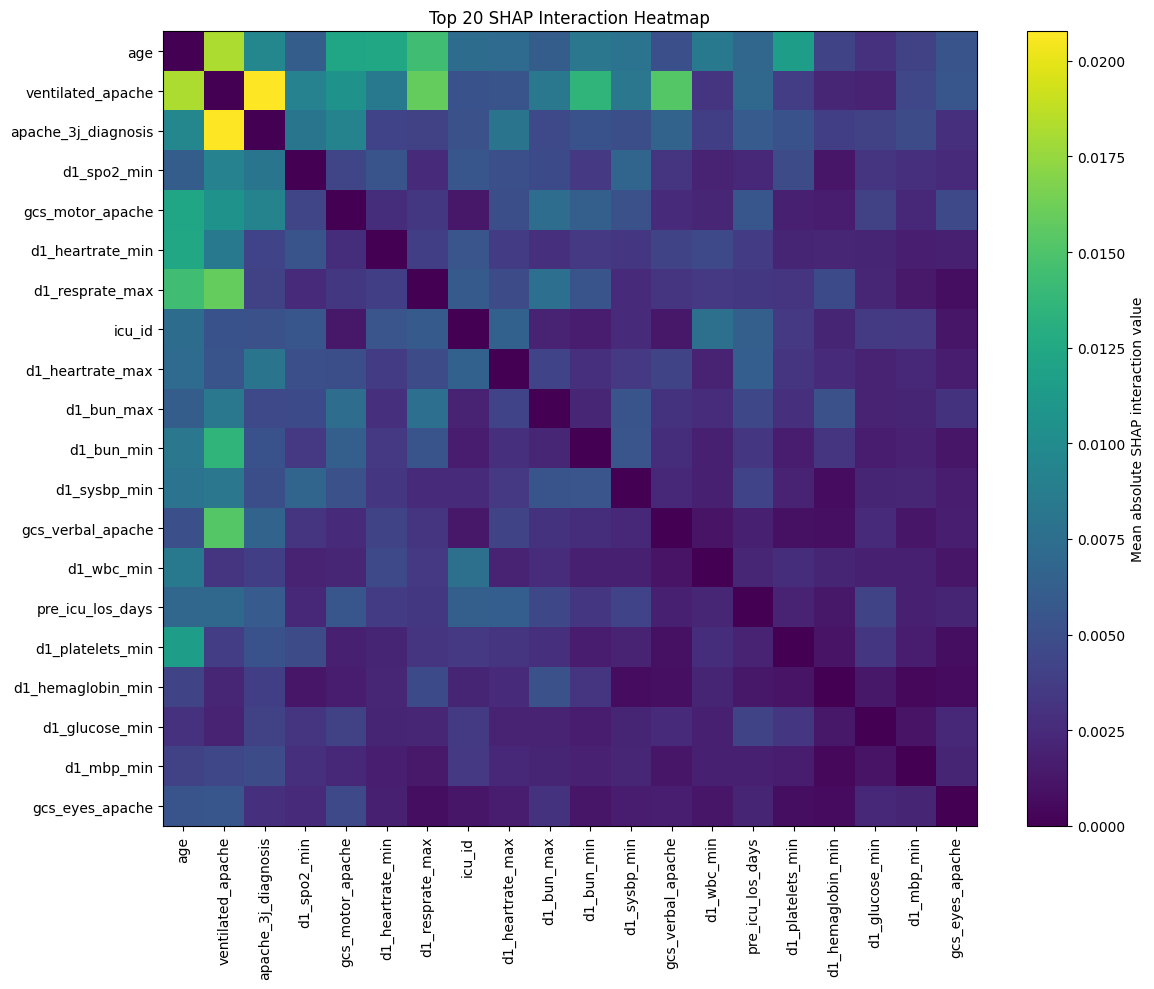

In [10]:
plt.figure(figsize=(12, 10))

im = plt.imshow(
    interaction_matrix_df,
    cmap="viridis",
    aspect="auto"
)

plt.colorbar(im, label="Mean absolute SHAP interaction value")

plt.xticks(
    ticks=np.arange(len(interaction_matrix_df.columns)),
    labels=interaction_matrix_df.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(interaction_matrix_df.index)),
    labels=interaction_matrix_df.index
)

plt.title("Top 20 SHAP Interaction Heatmap")
plt.tight_layout()

plt.savefig(
    explainability_dir / "top20_shap_interaction_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

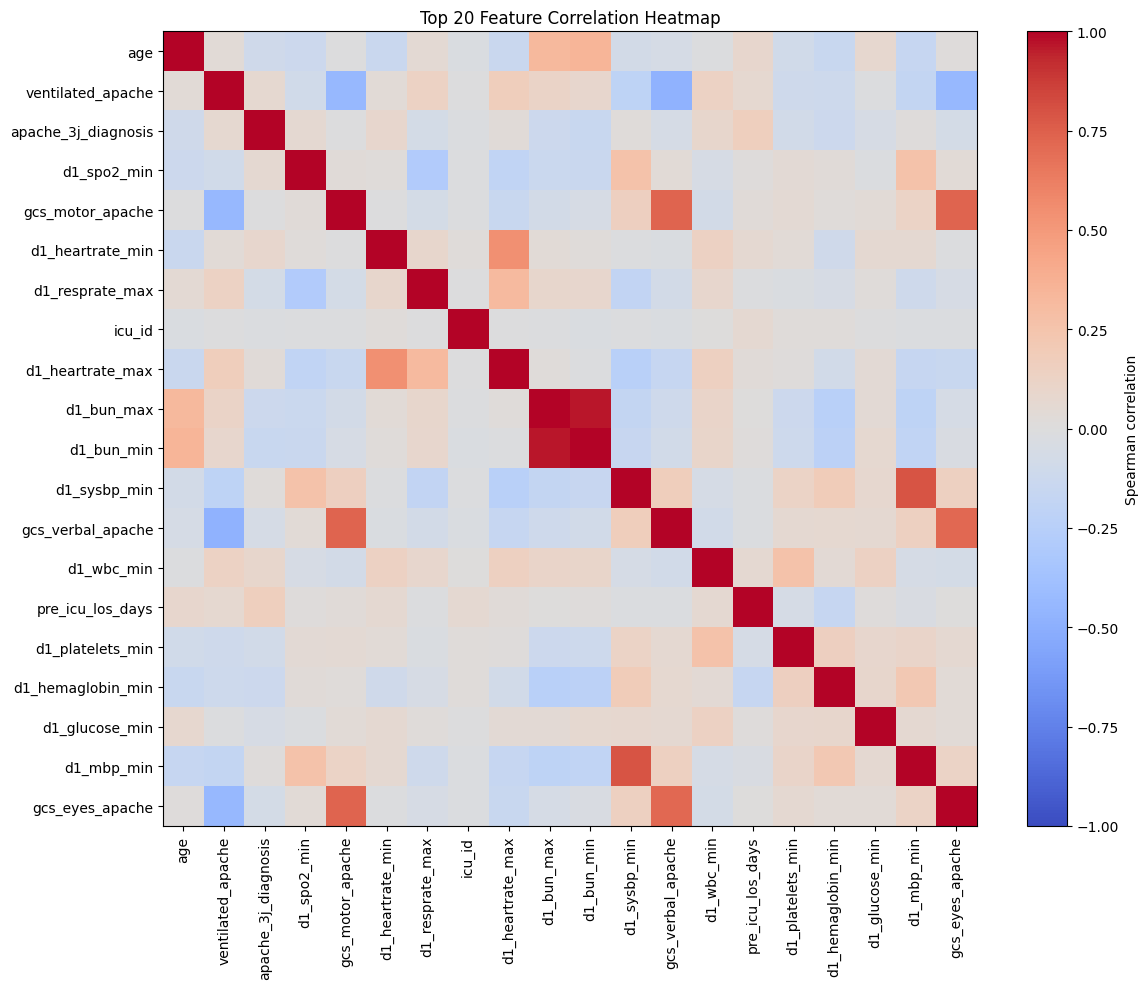

In [11]:
top20_corr = X_shap[top20_features].corr(method="spearman")

plt.figure(figsize=(12, 10))

im = plt.imshow(
    top20_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(im, label="Spearman correlation")

plt.xticks(
    ticks=np.arange(len(top20_corr.columns)),
    labels=top20_corr.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(top20_corr.index)),
    labels=top20_corr.index
)

plt.title("Top 20 Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    explainability_dir / "top20_feature_correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Caution Feature Analysis — `icu_id`

`icu_id` appeared among the globally important SHAP features, but it is not a direct patient-level clinical measurement. It likely represents ICU unit/location information and may capture unit-level patterns, case mix, documentation differences, or care-process differences.

This section does not remove `icu_id` from the model. Instead, it provides a lightweight justification for why `icu_id` should be treated as a caution-flagged feature in the evidence packet and LLM explanation pipeline.

In [12]:
# Load raw data for ICU-level descriptive analysis
raw_df = pd.read_csv("../data/raw/training_v2.csv")

icu_feature = "icu_id"

icu_global_shap = shap_importance[
    shap_importance["feature"] == icu_feature
].copy()

icu_global_shap

,feature,mean_abs_shap
7,icu_id,0.14655


In [13]:
icu_mortality = (
    raw_df
    .groupby("icu_id")["hospital_death"]
    .agg(
        n_patients="count",
        mortality_rate="mean"
    )
    .reset_index()
)

icu_mortality["mortality_rate_pct"] = (
    icu_mortality["mortality_rate"] * 100
).round(2)

icu_mortality_filtered = (
    icu_mortality
    .query("n_patients >= 100")
    .sort_values("mortality_rate", ascending=False)
    .reset_index(drop=True)
)

print(f"Total ICU IDs: {icu_mortality.shape[0]}")
print(f"ICU IDs with >=100 patients: {icu_mortality_filtered.shape[0]}")

icu_mortality_filtered.head(20)

Total ICU IDs: 241
ICU IDs with >=100 patients: 194


,icu_id,n_patients,mortality_rate,mortality_rate_pct
0,698,110,0.290909,29.09
1,290,302,0.201987,20.20
2,628,657,0.188737,18.87
3,632,492,0.178862,17.89
4,495,603,0.175788,17.58
5,256,309,0.174757,17.48
6,601,559,0.171735,17.17
7,285,413,0.162228,16.22
8,487,298,0.161074,16.11
9,513,820,0.159756,15.98


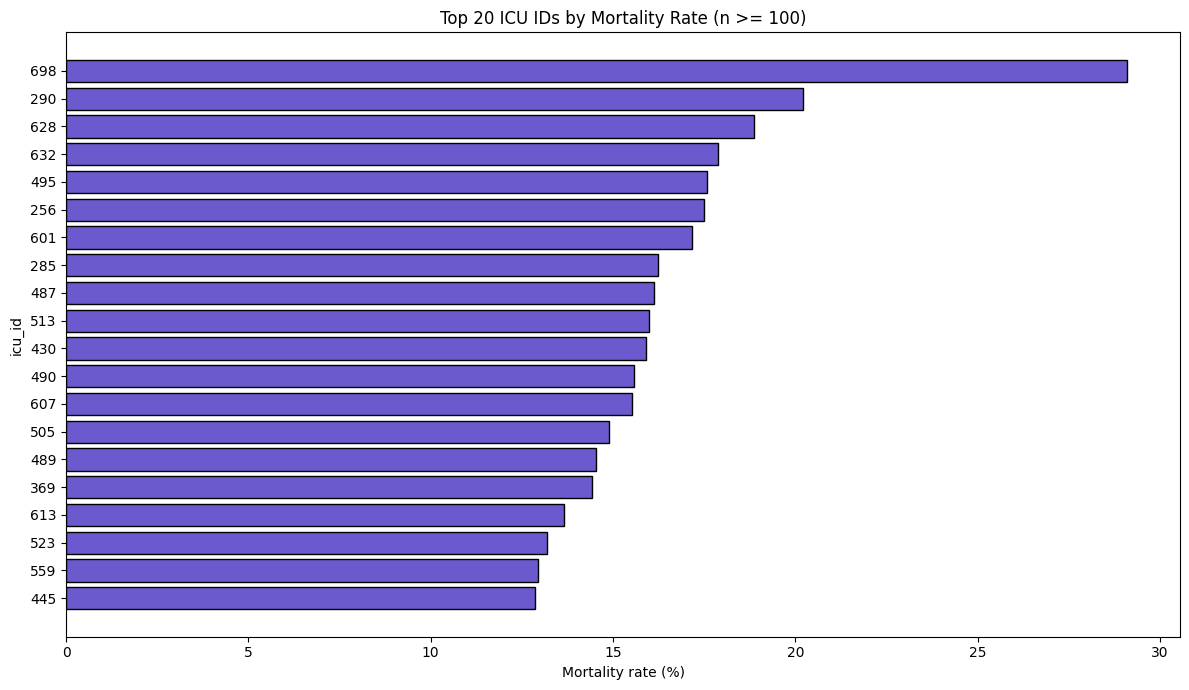

In [14]:
top_icu_mortality = icu_mortality_filtered.head(20).copy()

plt.figure(figsize=(12, 7))

plt.barh(
    top_icu_mortality["icu_id"].astype(str),
    top_icu_mortality["mortality_rate_pct"],
    color="slateblue",
    edgecolor="black"
)

plt.xlabel("Mortality rate (%)")
plt.ylabel("icu_id")
plt.title("Top 20 ICU IDs by Mortality Rate (n >= 100)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

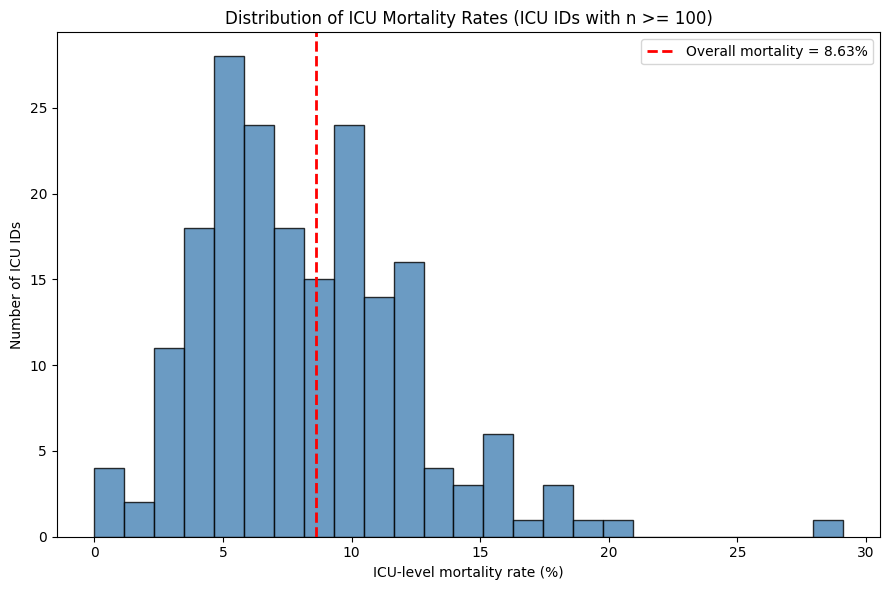

In [15]:
plt.figure(figsize=(9, 6))

plt.hist(
    icu_mortality_filtered["mortality_rate_pct"],
    bins=25,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    raw_df["hospital_death"].mean() * 100,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall mortality = {raw_df['hospital_death'].mean() * 100:.2f}%"
)

plt.xlabel("ICU-level mortality rate (%)")
plt.ylabel("Number of ICU IDs")
plt.title("Distribution of ICU Mortality Rates (ICU IDs with n >= 100)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
from pathlib import Path

caution_dir = Path("../reports/02_explainability/caution_analysis")
caution_dir.mkdir(parents=True, exist_ok=True)

icu_mortality_filtered.to_csv(
    caution_dir / "icu_id_mortality_by_unit.csv",
    index=False
)

icu_global_shap.to_csv(
    caution_dir / "icu_id_global_shap_importance.csv",
    index=False
)

print("Saved:")
print(caution_dir / "icu_id_mortality_by_unit.csv")
print(caution_dir / "icu_id_global_shap_importance.csv")

Saved:
../reports/02_explainability/caution_analysis/icu_id_mortality_by_unit.csv
../reports/02_explainability/caution_analysis/icu_id_global_shap_importance.csv


### Interpretation — Why `icu_id` receives a caution flag

`icu_id` appears among the globally important SHAP features, indicating that the model uses ICU unit/location information as a predictive signal. The ICU-level descriptive analysis also shows that mortality rates vary across ICU IDs with sufficient sample size.

However, `icu_id` is not a direct patient-level clinical measurement. It may reflect unit-level patterns, case mix, documentation differences, transfer pathways, or care-process differences rather than the patient's physiological status.

Therefore, `icu_id` was retained as model evidence but marked with a caution flag in the evidence packet. In generated explanations, it should be described as a non-clinical unit/location identifier and interpreted cautiously, not as a causal or direct clinical risk factor.